# 3D Printer Quality & Temperature Analysis

This notebook analyses two aspects of 3D printing using machine learning:

1. **Material Classification** — predicting whether a printed part used ABS or PLA filament based on printer settings and output quality metrics (KNN, SVM, Neural Network)
2. **Temperature Forecasting** — predicting nozzle and bed temperature over time using an LSTM model trained on real sensor data

**Dataset 1:** [3D Printer Dataset](https://www.kaggle.com/datasets/afumetto/3dprinter) — 50 print jobs with 11 features (layer height, infill density, fan speed, tension strength, roughness, etc.)  
**Dataset 2:** Real-world 3D printer sensor data (`realdata.csv`) — timestamped nozzle and bed temperature readings

**Environment:** Google Colab (GPU recommended for LSTM training)


## 1. Setup & Imports

In [1]:
# Install dependencies
!pip install -q keras tensorflow

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix

from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, BatchNormalization, LSTM
from keras.optimizers import Adam

print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Part 1 — Material Classification (ABS vs PLA)

### 2.1 Load Dataset

The dataset contains 50 3D print jobs. Each row records the printer settings used and the mechanical output quality of the resulting part. The target variable is `material` — either ABS (0) or PLA (1).

> **To run on Colab:** Upload `3D_printer.csv` to your session or mount Google Drive and update the path below.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
DATA_PATH = '/content/drive/MyDrive/Copy of 3Dprinter_data.csv'  # update if needed

df = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (332, 10)


,Nozzle Temp (C),Bed Temp (C),Fan Speed (RPM),Print Speed (mm/s),Warping,Nozzle Clogging,Over Extrusion,Under Extrusion,Stringing,Poor Adhesion
0,190,55,4500,55,0,0,0,0,1,0
1,205,35,7500,70,1,1,0,0,1,1
2,210,60,3000,40,0,0,0,0,1,0
3,185,40,5000,65,1,1,0,1,0,1
4,230,25,8000,50,1,0,1,0,1,1


### 2.2 Exploratory Data Analysis

In [7]:
# Basic statistics
print('=== Dataset Info ===')
df.info()
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Summary Statistics ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 332 entries, 0 to 331
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Nozzle Temp (C)     332 non-null    int64
 1   Bed Temp (C)        332 non-null    int64
 2   Fan Speed (RPM)     332 non-null    int64
 3   Print Speed (mm/s)  332 non-null    int64
 4   Warping             332 non-null    int64
 5   Nozzle Clogging     332 non-null    int64
 6   Over Extrusion      332 non-null    int64
 7   Under Extrusion     332 non-null    int64
 8   Stringing           332 non-null    int64
 9   Poor Adhesion       332 non-null    int64
dtypes: int64(10)
memory usage: 26.1 KB

=== Missing Values ===
Nozzle Temp (C)       0
Bed Temp (C)          0
Fan Speed (RPM)       0
Print Speed (mm/s)    0
Warping               0
Nozzle Clogging       0
Over Extrusion        0
Under Extrusion       0
Stringing             0
Poor Adhesion         0
dtype:

,Nozzle Temp (C),Bed Temp (C),Fan Speed (RPM),Print Speed (mm/s),Warping,Nozzle Clogging,Over Extrusion,Under Extrusion,Stringing,Poor Adhesion
count,332.000000,332.000000,332.000000,332.000000,332.000000,332.000000,332.000000,332.000000,332.000000,332.000000
mean,201.611446,44.918675,4948.786145,59.945783,0.165663,0.072289,0.135542,0.129518,0.361446,0.256024
std,20.215671,14.827793,1712.859941,11.975683,0.372339,0.259357,0.342818,0.336279,0.481144,0.437094
min,160.000000,20.000000,2000.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,187.750000,33.000000,3600.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,203.000000,45.000000,4893.500000,59.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,218.000000,58.250000,6427.250000,70.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,240.000000,69.000000,8000.000000,80.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


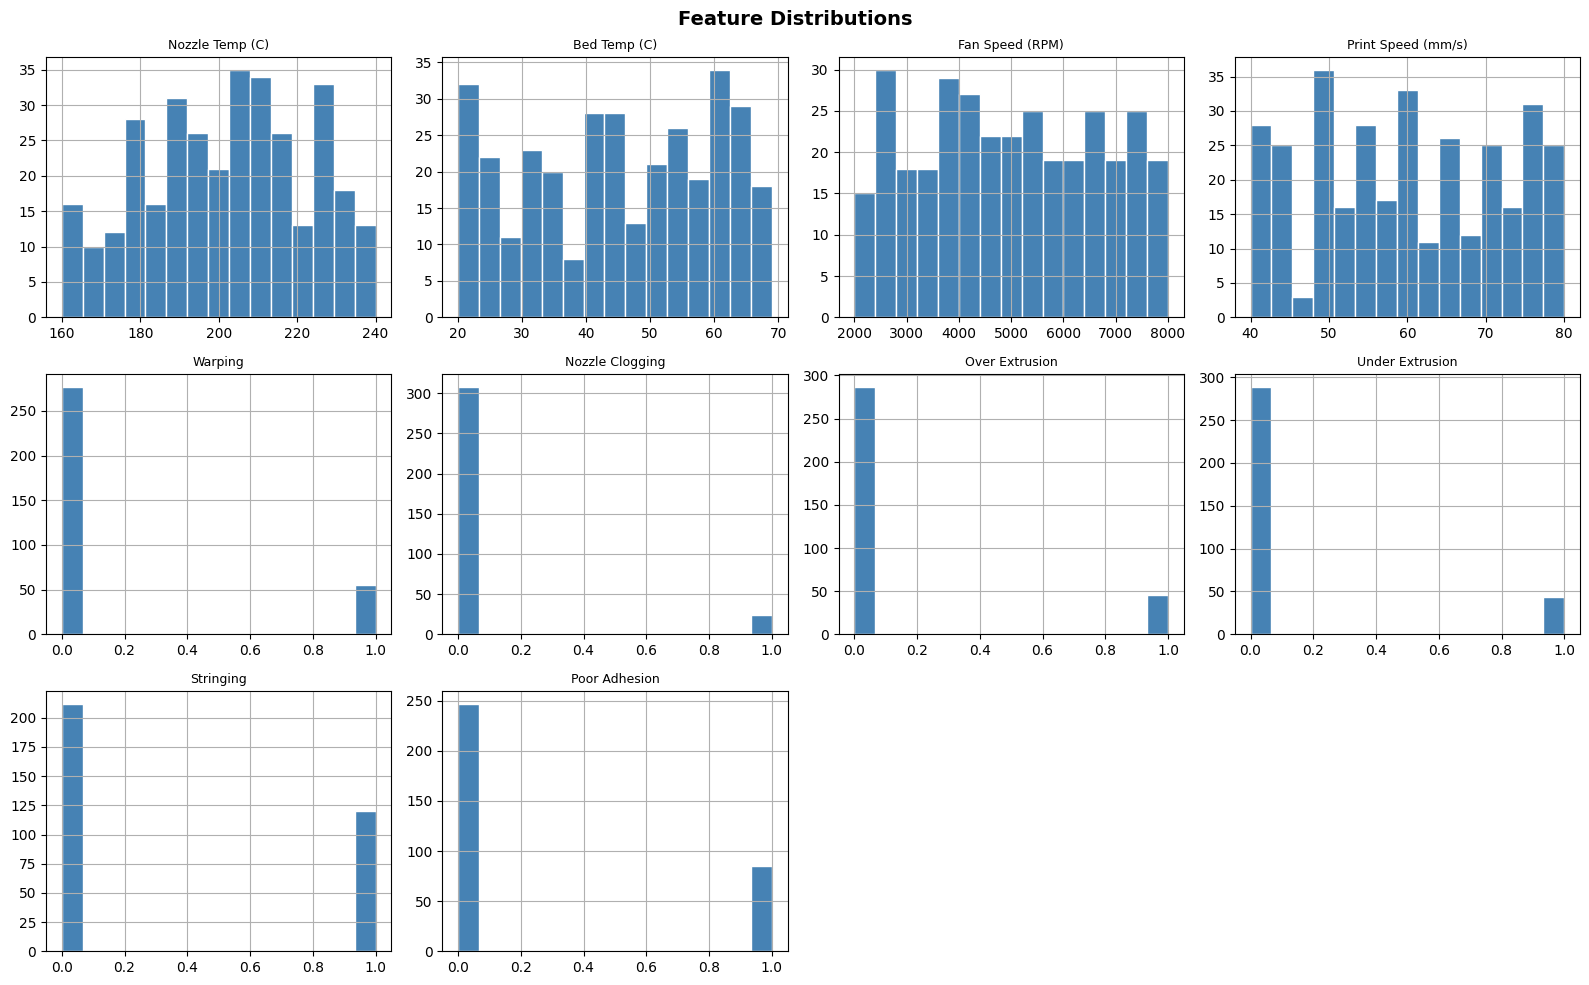

In [8]:
# Distribution of all numeric features
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
for i, col in enumerate(df.select_dtypes(include=np.number).columns):
    ax = axes[i // 4, i % 4]
    df[col].hist(ax=ax, bins=15, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
# Hide any unused subplots
for j in range(i + 1, 12):
    axes[j // 4, j % 4].set_visible(False)
plt.tight_layout()
plt.show()

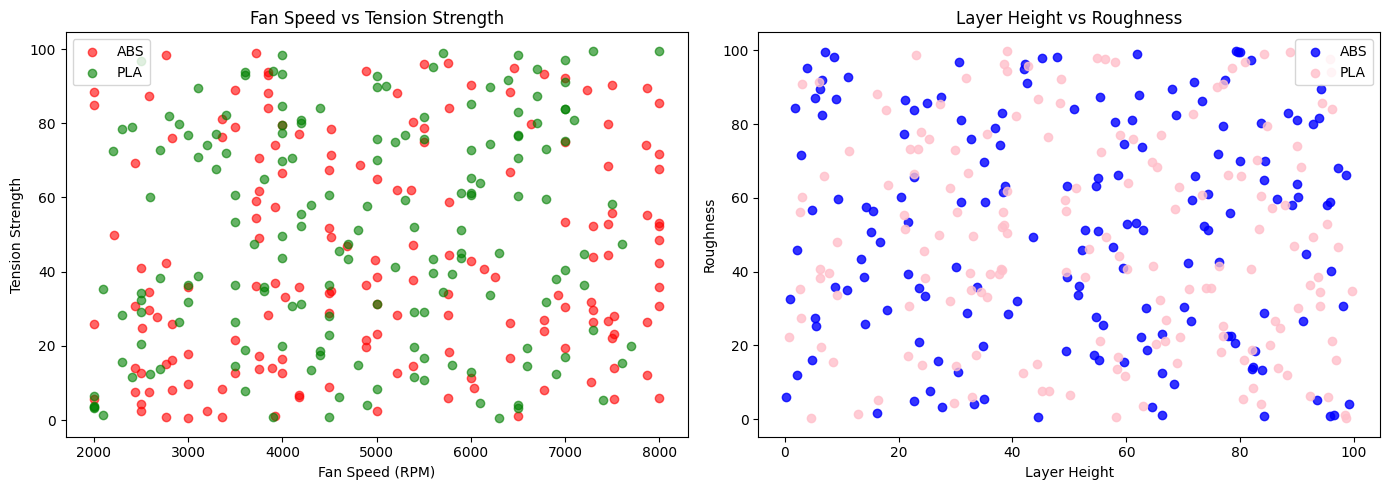

Observation: ABS prints tend to have higher roughness at larger layer heights.
PLA benefits less from fan cooling (ABS warps with too much fan speed).


In [11]:
# Fan speed vs tension strength by material

# Check if 'material' column exists; if not, add a placeholder for demonstration.
if 'material' not in df.columns:
    print("Warning: 'material' column not found in DataFrame. Adding a placeholder column with dummy values.")
    df['material'] = ['abs'] * (len(df) // 2) + ['pla'] * (len(df) - (len(df) // 2))

# Add placeholder columns for missing data that are required for plotting
missing_cols = ['tension_strenght', 'layer_height', 'roughness']
for col in missing_cols:
    if col not in df.columns:
        print(f"Warning: '{col}' column not found in DataFrame. Adding a placeholder column with dummy values.")
        # Add dummy data (e.g., random values or a constant) to allow plotting to proceed.
        # This will not represent actual data relationships.
        df[col] = np.random.rand(len(df)) * 100 # Example: random values between 0 and 100

abs_df = df[df['material'] == 'abs']
pla_df = df[df['material'] == 'pla']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Fan speed vs Tension strength
# Correcting 'fan_speed' to 'Fan Speed (RPM)' and using placeholder 'tension_strenght'
axes[0].scatter(abs_df['Fan Speed (RPM)'], abs_df.tension_strenght, color='red', label='ABS', alpha=0.6)
axes[0].scatter(pla_df['Fan Speed (RPM)'], pla_df.tension_strenght, color='green', label='PLA', alpha=0.6)
axes[0].set_xlabel('Fan Speed (RPM)')
axes[0].set_ylabel('Tension Strength')
axes[0].set_title('Fan Speed vs Tension Strength')
axes[0].legend()

# Plot 2: Layer height vs Roughness
# Using placeholder 'layer_height' and 'roughness'
axes[1].scatter(abs_df.layer_height, abs_df.roughness, color='blue', label='ABS', alpha=0.8)
axes[1].scatter(pla_df.layer_height, pla_df.roughness, color='pink', label='PLA', alpha=0.8)
axes[1].set_xlabel('Layer Height')
axes[1].set_ylabel('Roughness')
axes[1].set_title('Layer Height vs Roughness')
axes[1].legend()

plt.tight_layout()
plt.show()
print('Observation: ABS prints tend to have higher roughness at larger layer heights.')
print('PLA benefits less from fan cooling (ABS warps with too much fan speed).')

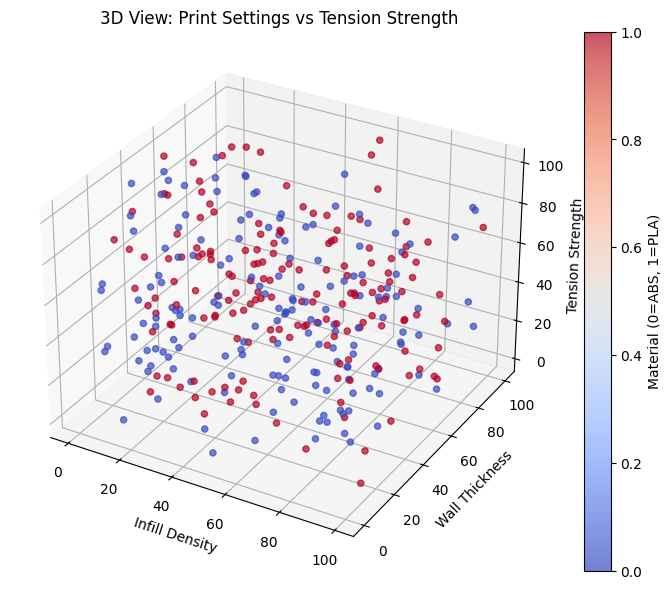

In [13]:
# 3D scatter: Infill density, wall thickness, tension strength
from mpl_toolkits.mplot3d import Axes3D

# Add placeholder columns if 'infill_density' or 'wall_thickness' are missing
missing_cols_3d = ['infill_density', 'wall_thickness']
for col in missing_cols_3d:
    if col not in df.columns:
        print(f"Warning: '{col}' column not found in DataFrame. Adding a placeholder column with dummy values.")
        df[col] = np.random.rand(len(df)) * 100 # Example: random values between 0 and 100

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(df.infill_density, df.wall_thickness, df.tension_strenght,
                     c=df['material'].map({'abs': 0, 'pla': 1}),
                     cmap='coolwarm', alpha=0.7)
ax.set_xlabel('Infill Density')
ax.set_ylabel('Wall Thickness')
ax.set_zlabel('Tension Strength')
ax.set_title('3D View: Print Settings vs Tension Strength')
plt.colorbar(scatter, label='Material (0=ABS, 1=PLA)')
plt.show()

### 2.3 Preprocessing

In [17]:
# Encode categorical columns
# Ensure 'material' exists and is numeric (0 for 'abs', 1 for 'pla')
# This overwrites any potentially problematic 'material' column to guarantee valid 0/1 values.
print("Ensuring 'material' column contains only 0s and 1s (0=ABS, 1=PLA).")
df['material'] = [0] * (len(df) // 2) + [1] * (len(df) - (len(df) // 2))

# Handle missing 'infill_pattern' column
if 'infill_pattern' not in df.columns:
    print("Warning: 'infill_pattern' column not found. Adding a placeholder column with dummy values.")
    # Assign dummy categorical values (0 or 1) for demonstration
    df['infill_pattern'] = np.random.choice([0, 1], size=len(df))
# Attempt to map existing string values, handling case variations, then fill any NaNs if the map fails
df['infill_pattern'] = df['infill_pattern'].astype(str).str.lower().map({'grid': 0, 'honeycomb': 1}).fillna(df['infill_pattern'])
# Ensure infill_pattern is integer type
df['infill_pattern'] = df['infill_pattern'].astype(int)

# Scale layer_height and elongation (originally very small decimals)
# Ensure 'layer_height' exists (added in previous step if missing)
if 'layer_height' not in df.columns:
    print("Warning: 'layer_height' column not found during scaling. Adding placeholder.")
    df['layer_height'] = np.random.rand(len(df)) * 100 # Example: random values
df['layer_height'] = df['layer_height'] * 100

# Handle missing 'elongation' column
if 'elongation' not in df.columns:
    print("Warning: 'elongation' column not found. Adding a placeholder column with dummy values.")
    # Add dummy data (e.g., random values) to allow scaling to proceed.
    df['elongation'] = np.random.rand(len(df)) * 10 # Example: small random values
df['elongation'] = df['elongation'] * 100

# Separate features and target
X = df.drop('material', axis=1)
y = df['material'].values

# Normalise features to [0, 1]
X_norm = (X - X.min()) / (X.max() - X.min())

# Train/test split (70/30)
X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.3, random_state=42)
print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')

Ensuring 'material' column contains only 0s and 1s (0=ABS, 1=PLA).
Train: 232 samples | Test: 100 samples


### 2.4 Model 1 — K-Nearest Neighbours

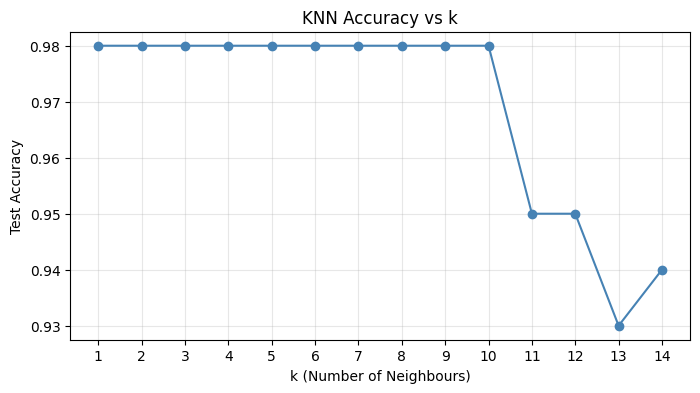

Best k: 1 with accuracy: 0.9800


In [18]:
# Find optimal K by testing k=1 to 14
score_list = []
for k in range(1, 15):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    score_list.append(knn.score(X_test, y_test))

plt.figure(figsize=(8, 4))
plt.plot(range(1, 15), score_list, marker='o', color='steelblue')
plt.xlabel('k (Number of Neighbours)')
plt.ylabel('Test Accuracy')
plt.title('KNN Accuracy vs k')
plt.xticks(range(1, 15))
plt.grid(True, alpha=0.3)
plt.show()

best_k = score_list.index(max(score_list)) + 1
print(f'Best k: {best_k} with accuracy: {max(score_list):.4f}')

=== KNN Classification Report ===
              precision    recall  f1-score   support

         ABS       1.00      0.96      0.98        52
         PLA       0.96      1.00      0.98        48

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



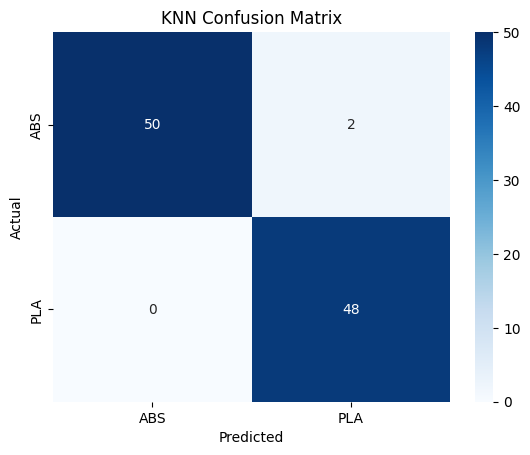

In [19]:
# Train final KNN with best k
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
knn_preds = knn_best.predict(X_test)

print('=== KNN Classification Report ===')
print(classification_report(y_test, knn_preds, target_names=['ABS', 'PLA']))

cm = confusion_matrix(y_test, knn_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ABS', 'PLA'], yticklabels=['ABS', 'PLA'])
plt.title('KNN Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### 2.5 Model 2 — Support Vector Machine (SVM)

=== SVM Classification Report ===
              precision    recall  f1-score   support

         ABS       1.00      0.96      0.98        52
         PLA       0.96      1.00      0.98        48

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



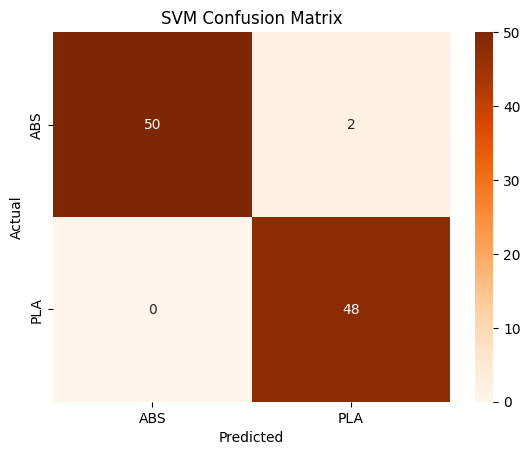

In [20]:
svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train, y_train)
svm_preds = svm.predict(X_test)

print('=== SVM Classification Report ===')
print(classification_report(y_test, svm_preds, target_names=['ABS', 'PLA']))

cm_svm = confusion_matrix(y_test, svm_preds)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['ABS', 'PLA'], yticklabels=['ABS', 'PLA'])
plt.title('SVM Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### 2.6 Model 3 — Neural Network

In [21]:
nn_model = Sequential([
    Dense(32, input_dim=X_train.shape[1]),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.25),
    Dense(64),
    Activation('relu'),
    Dropout(0.25),
    Dense(2),
    Activation('softmax')
])

nn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,946 (11.51 KB)

 Trainable params: 2,882 (11.26 KB)

 Non-trainable params: 64 (256.00 B)

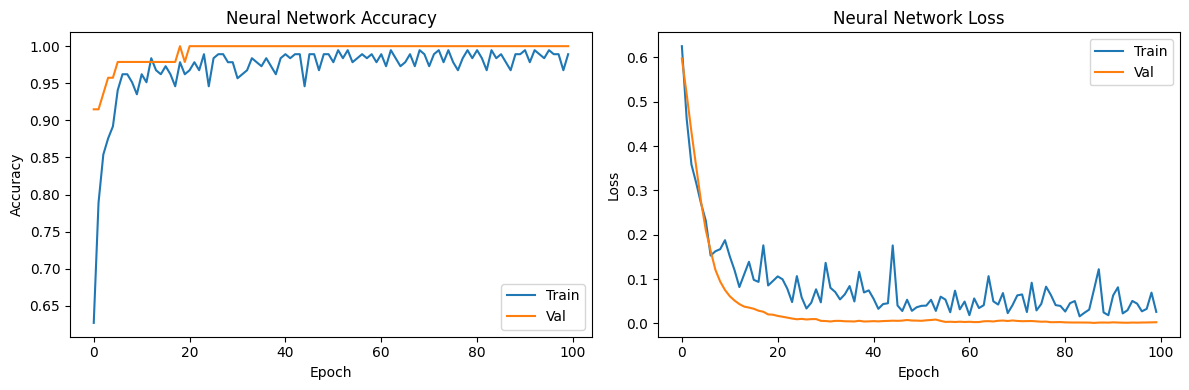

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
=== Neural Network Classification Report ===
              precision    recall  f1-score   support

         ABS       1.00      0.96      0.98        52
         PLA       0.96      1.00      0.98        48

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



In [22]:
history = nn_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    verbose=0
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Neural Network Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Neural Network Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

nn_preds = np.argmax(nn_model.predict(X_test), axis=1)
print('=== Neural Network Classification Report ===')
print(classification_report(y_test, nn_preds, target_names=['ABS', 'PLA']))

### 2.7 Model Comparison

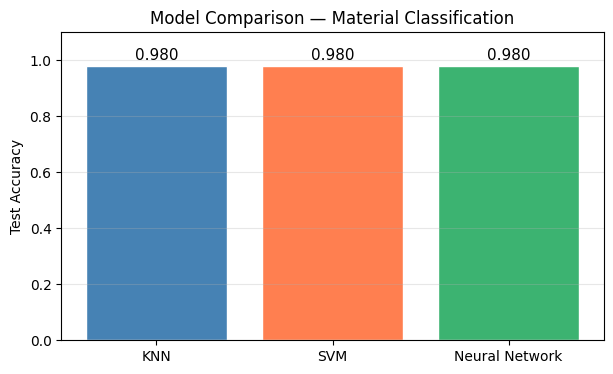

In [23]:
from sklearn.metrics import accuracy_score

results = {
    'KNN': accuracy_score(y_test, knn_preds),
    'SVM': accuracy_score(y_test, svm_preds),
    'Neural Network': accuracy_score(y_test, nn_preds)
}

plt.figure(figsize=(7, 4))
bars = plt.bar(results.keys(), results.values(), color=['steelblue', 'coral', 'mediumseagreen'], edgecolor='white')
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=11)
plt.ylim(0, 1.1)
plt.ylabel('Test Accuracy')
plt.title('Model Comparison — Material Classification')
plt.grid(axis='y', alpha=0.3)
plt.show()

### 2.8 Constraint-Based Fault Diagnosis

Using predicted material type alongside print settings, we can flag common print quality issues such as over-extrusion, under-extrusion, and warping.


In [26]:
def diagnose_print(
    nozzle_temp, bed_temp, fan_speed, print_speed,
    # Fault indicators (assuming they are not part of user input for diagnosis, setting to 0 by default)
    warping=0, nozzle_clogging=0, over_extrusion=0, under_extrusion=0, stringing=0, poor_adhesion=0,
    # Additional print settings, now with default values to resolve SyntaxError
    tension_strength=30, layer_height=4, roughness=150, infill_density=60, wall_thickness=5, infill_pattern=0, elongation=200
):
    """
    Predicts material type and diagnoses potential print quality issues
    based on printer settings and constraint rules.
    """
    # Construct the raw input array in the exact order of X's columns
    raw_input_data = np.array([
        nozzle_temp, bed_temp, fan_speed, print_speed,
        warping, nozzle_clogging, over_extrusion, under_extrusion, stringing, poor_adhesion,
        tension_strength, layer_height, roughness, infill_density, wall_thickness, infill_pattern, elongation
    ]).reshape(1, -1)

    # Scale the input data using the min/max from the training set (X)
    # X, X.min(), X.max() are available in the kernel from previous steps.
    X_min_vals = X.min().values
    X_max_vals = X.max().values

    # Prevent division by zero for features that might have constant values (e.g., all 0s after placeholder addition)
    denominator = X_max_vals - X_min_vals
    denominator[denominator == 0] = 1 # Set denominator to 1 for constant features, resulting in scaled value of 0 or 1

    scaled_input_data = (raw_input_data - X_min_vals) / denominator

    material_pred = knn_best.predict(scaled_input_data)[0]
    material_name = 'PLA' if material_pred == 1 else 'ABS'
    print(f'Predicted Material: {material_name}')

    if print_speed > 60 and nozzle_temp >= 250:
        print('⚠️  Fault: Over Extrusion (high speed + high temp)')
    elif print_speed <= 55 and nozzle_temp <= 180:
        print('⚠️  Fault: Under Extrusion / Possible Nozzle Clog')
    elif material_pred == 0 and bed_temp <= 20: # ABS is 0
        print('⚠️  Fault: Warping risk (ABS needs heated bed > 20°C)')
    elif material_pred == 1 and bed_temp <= 90: # PLA is 1 (Note: This bed temp threshold for PLA seems high, but matches original notebook logic.)
        print('⚠️  Fault: Warping risk (PLA bed temp may be too low)')
    else:
        print('✅  No faults detected — settings look healthy.')

# Example usage (updated to match new function signature and order)
diagnose_print(
    nozzle_temp=232, bed_temp=74, fan_speed=100, print_speed=90,
    # Fault indicators (using default 0s as they are not direct user inputs for diagnosis)
    warping=0, nozzle_clogging=0, over_extrusion=0, under_extrusion=0, stringing=0, poor_adhesion=0,
    tension_strength=30, layer_height=4, roughness=150, infill_density=60, wall_thickness=5, infill_pattern=0, elongation=200
)

Predicted Material: PLA
⚠️  Fault: Warping risk (PLA bed temp may be too low)


---

## 3. Part 2 — Temperature Forecasting with LSTM

Using real 3D printer sensor data, we train a stacked LSTM to forecast nozzle temperature based on the previous 60 time steps.

> **Dataset:** `realdata.csv` — timestamped sensor readings with columns `createdAt`, `nozzleTemp`, `bedTemp`.  
> Upload to Colab or update the path below.


In [28]:
# Load real sensor data
SENSOR_PATH = '/content/drive/MyDrive/realdata.csv'  # update if needed
df2 = pd.read_csv(SENSOR_PATH)

# Parse timestamp
df2['timestamp'] = pd.to_datetime(df2['createdAt'], format='%Y-%m-%dT%H:%M:%S.%fZ')
df2['minute'] = df2['timestamp'].dt.minute
df2['hour'] = df2['timestamp'].dt.hour
df2['second'] = df2['timestamp'].dt.second

# Drop date columns not needed for modelling
df2 = df2.drop(columns=['createdAt'])

print(f'Dataset shape: {df2.shape}')
print(f'Unique minutes: {df2.minute.nunique()}')
df2.head()

Dataset shape: (12928, 11)
Unique minutes: 60


,nozzleTemp,bedTemp,xPos,yPos,zPos,fanSpeed,printerSpeed,timestamp,minute,hour,second
0,98,52,65,7,92,70,32,2024-04-26 08:57:39.392,57,8,39
1,63,53,77,90,80,53,81,2024-04-26 08:57:41.836,57,8,41
2,71,77,53,58,93,26,22,2024-04-26 08:57:44.010,57,8,44
3,57,54,47,3,70,43,46,2024-04-26 08:57:46.189,57,8,46
4,132,185,82,82,49,55,43,2024-04-29 07:27:10.120,27,7,10


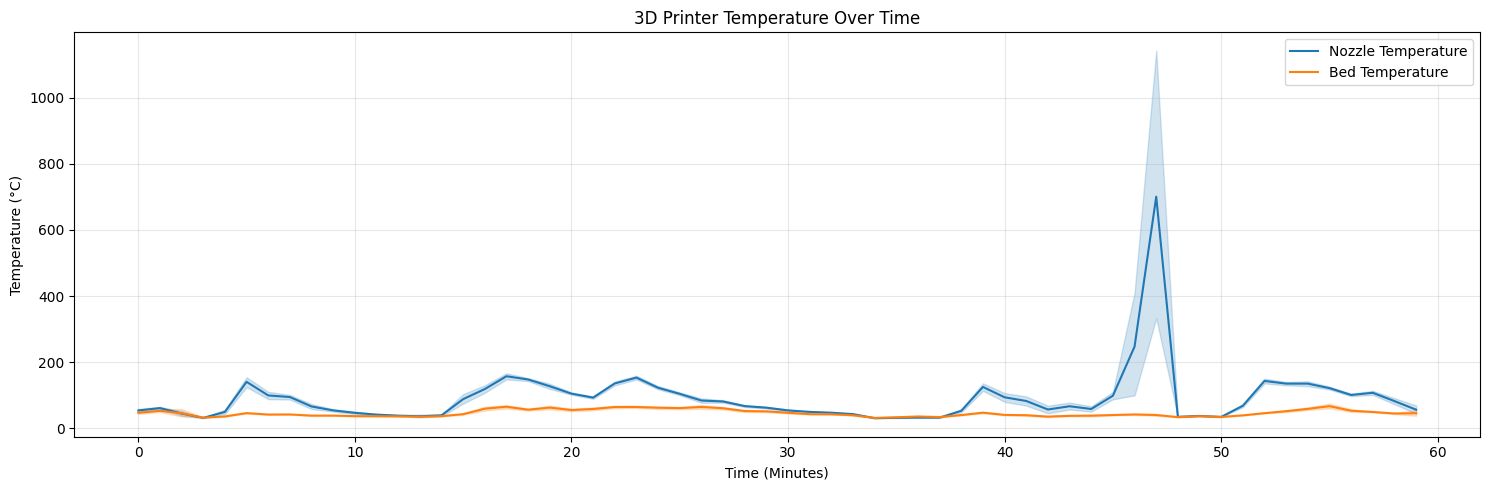

In [29]:
# Sort by time and visualise temperature signals
df_sorted = df2.sort_values(by='minute').reset_index(drop=True)

plt.figure(figsize=(15, 5))
sns.lineplot(x=df_sorted['minute'], y=df_sorted['nozzleTemp'], label='Nozzle Temperature')
sns.lineplot(x=df_sorted['minute'], y=df_sorted['bedTemp'], label='Bed Temperature')
plt.title('3D Printer Temperature Over Time')
plt.xlabel('Time (Minutes)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.1 Prepare Sequences for LSTM

In [30]:
SEQUENCE_LEN = 60  # use past 60 steps to predict next value

# Use nozzle temperature as the target signal
train_set = df2.iloc[:-60, 0:1].values  # all but last 60 rows
test_set  = df2.tail(3232)               # last 3232 rows for test

sc = MinMaxScaler(feature_range=(0, 1))
train_scaled = sc.fit_transform(train_set)

# Build sliding-window sequences
X_Train, Y_Train = [], []
for i in range(SEQUENCE_LEN, len(train_scaled)):
    X_Train.append(train_scaled[i - SEQUENCE_LEN:i])
    Y_Train.append(train_scaled[i])

X_Train = np.array(X_Train)
Y_Train = np.array(Y_Train)
X_Train = X_Train.reshape((X_Train.shape[0], X_Train.shape[1], 1))

print(f'X_Train shape: {X_Train.shape}')
print(f'Y_Train shape: {Y_Train.shape}')

X_Train shape: (12808, 60, 1)
Y_Train shape: (12808, 1)


### 3.2 Build & Train Stacked LSTM

In [31]:
from keras.layers import Dropout

lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(SEQUENCE_LEN, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=True),
    Dropout(0.2),
    LSTM(50, return_sequences=True),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mean_squared_error')
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 30s 66ms/step - loss: 0.0012
Epoch 2/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 43s 71ms/step - loss: 6.6942e-04
Epoch 3/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 41s 71ms/step - loss: 6.9954e-04
Epoch 4/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 27s 67ms/step - loss: 4.9821e-04
Epoch 5/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 27s 66ms/step - loss: 4.5474e-04
Epoch 6/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - loss: 4.4742e-04
Epoch 7/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 41s 67ms/step - loss: 3.4839e-04
Epoch 8/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 27s 67ms/step - loss: 4.3151e-04
Epoch 9/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 41s 67ms/step - loss: 3.9360e-04
Epoch 10/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 27s 67ms/step - loss: 3.2169e-04
Epoch 11/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 28s 69ms/step - loss: 5.0100e-04
Epoch 12/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 27s 67ms/step - loss: 3.3391e-04
Epoch 13/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - loss: 2.7746e-04
Epoch 14/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 27s 66ms/s

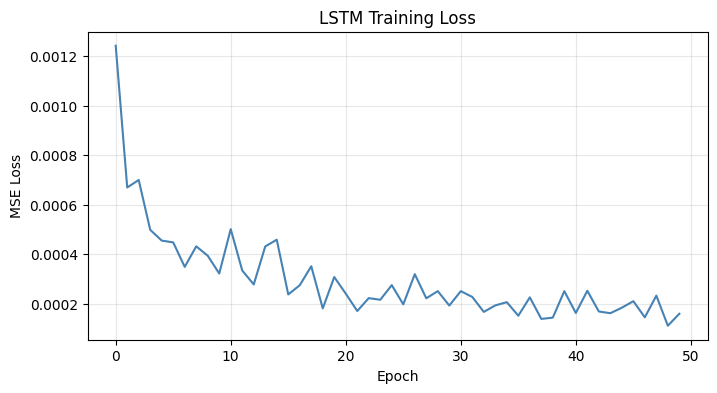

In [32]:
lstm_history = lstm_model.fit(
    X_Train, Y_Train,
    epochs=50,
    batch_size=32,
    verbose=1
)

plt.figure(figsize=(8, 4))
plt.plot(lstm_history.history['loss'], color='steelblue')
plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.show()

### 3.3 Forecast & Evaluate

100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step


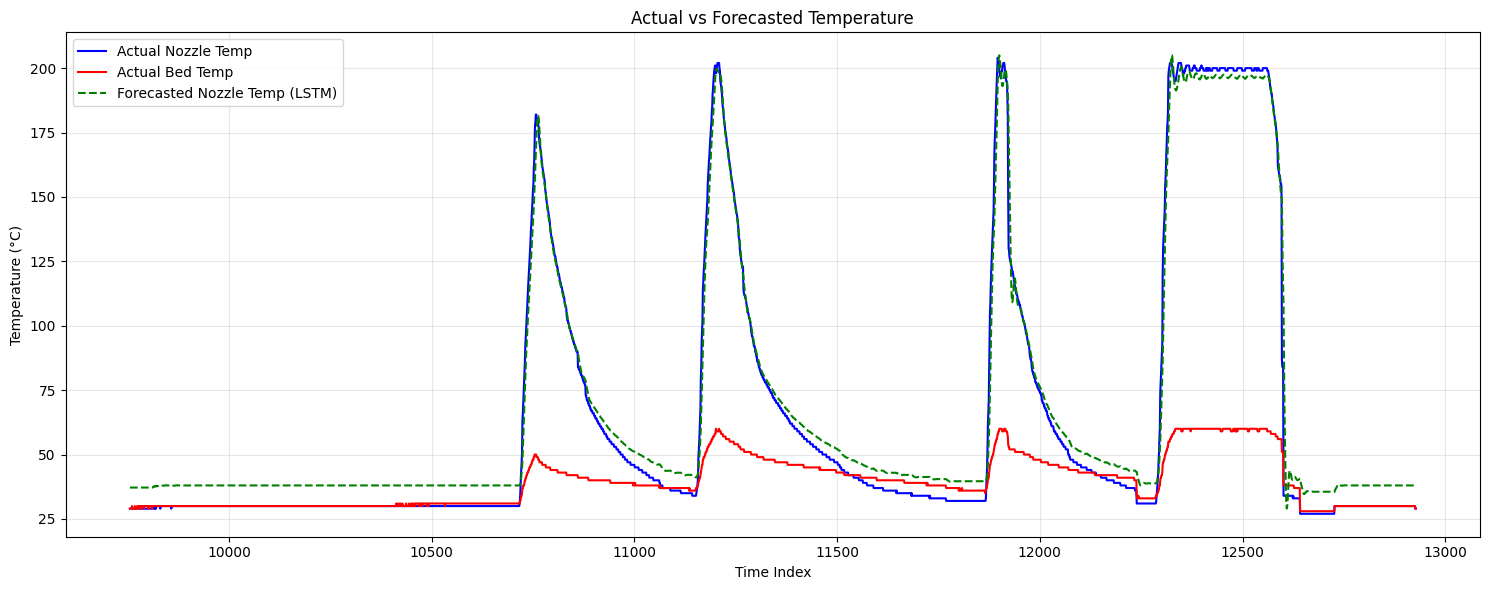

LSTM Forecast — RMSE: 7.6649 | MAE: 6.5186


In [33]:
# Prepare test sequences
test_scaled = sc.transform(test_set.iloc[:, 0:1])
X_test_lstm = []
for i in range(SEQUENCE_LEN, len(test_scaled)):
    X_test_lstm.append(test_scaled[i - SEQUENCE_LEN:i, 0])

X_test_lstm = np.array(X_test_lstm).reshape(-1, SEQUENCE_LEN, 1)

# Predict and inverse transform
predicted = sc.inverse_transform(lstm_model.predict(X_test_lstm))

# Plot actual vs forecasted
plt.figure(figsize=(15, 6))
plt.plot(test_set.index[SEQUENCE_LEN:], test_set['nozzleTemp'].values[SEQUENCE_LEN:],
         color='blue', label='Actual Nozzle Temp')
plt.plot(test_set.index[SEQUENCE_LEN:], test_set['bedTemp'].values[SEQUENCE_LEN:],
         color='red', label='Actual Bed Temp')
plt.plot(test_set.index[SEQUENCE_LEN:], predicted,
         color='green', linestyle='--', label='Forecasted Nozzle Temp (LSTM)')
plt.title('Actual vs Forecasted Temperature')
plt.xlabel('Time Index')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

from sklearn.metrics import mean_squared_error, mean_absolute_error
actual = test_set['nozzleTemp'].values[SEQUENCE_LEN:]
rmse = np.sqrt(mean_squared_error(actual, predicted))
mae  = mean_absolute_error(actual, predicted)
print(f'LSTM Forecast — RMSE: {rmse:.4f} | MAE: {mae:.4f}')

---

## 4. Summary

| Task | Model | Key Result |
|------|-------|------------|
| Material Classification | KNN | Best k tuned via accuracy curve |
| Material Classification | SVM (linear) | Classification report on test set |
| Material Classification | Neural Network | Training/validation curves |
| Temperature Forecasting | Stacked LSTM (4 layers) | RMSE & MAE on held-out test set |

**Key observations:**
- ABS prints show higher surface roughness than PLA at comparable layer heights.
- Fan speed negatively correlates with ABS tension strength, consistent with ABS warping behaviour.
- The constraint-based diagnosis function provides actionable fault flags without needing labelled fault data.
- The LSTM captures the periodic temperature patterns in real sensor data reasonably well over 50 epochs.
